# Classificação de clientes bancários com o K-Nearest Neighbors
=======================================

**Disciplina:** Aprendizado de máquina 

**Professor**: Daniel Roberto Cassar 

**Aluna:** Bruna Henrique Fujihashi

**Monstro:** Cubo gelatinoso



## Introdução 

No mundo que gira em torno do armazenamento de dados, seja para fins de documentação ou avaliação do comportamento de um fenônemo. No âmbito de aprender com os dados armazenados, o aprendizado de máquina torna-se uma ferramenta podererosa e essencial para analisar e prever comportamentos a partir dos dados utilizados para treinar um modelo [1]. No trabalho realizado por Sérgio Moro, Paulo Cortez e Paulo Rita [2], foram coletados dados de uma campanha de telemarketing de uma instituição bancária portuguesa, que coletava informações de seus cliente - como idade, tempo da ligação, emprego - com o intuito de de saber se esse cliente contrataria ou não um empréstimo bancário a longo prazo. 

A partir do conjunto de dados disponibilizado pelos autores no repositório de aprendizado de máquina da University of California Irvine(UCI)[3], foi desenvolvido um trabalho voltado a nota parcial da disciplina de Aprendizado de Máquina, lecionada pelo professor Daniel Roberto Cassar, que tem o objetivo de treinar um modelo preditivo partindo de um conjunto de dados da escolha do aluno. Para isso, será utilizado o algoritmo de K-Nearest Neighbors(KNN) paa prever a adesão dos clientes ao empréstimo. Esse algoritmo consiste em encontrar um número pré-definido de amostras de treino mais próximas em distância do novo ponto, e prever um rótulo a partir delas[3]. Ele é considerado um algoritmo preguiçoso, já que memoriza somente os objetos de treinamento[1]. 

Neste trabalho, vão ser exploradas as formas de treinar o modelo com o algotitmo KNN desde a utilizar dados normalizados ou não normalizados até a variação dos hiperparâmetros na hora de treinar o modelo preditivo. Além do número de vizinhos ser variado, esperasse que haja observação da variação do tipo de função de distância dentre 3 principais previamente escoolhidas: a euclidiana, a manhattan e o chebyshev. A distância euclidiana é a mais conhecida dentre as 3 e diz respeito ao segmento de reta que mede a distância entre dois pontos em um espaço euclidiano[4]. A distância de Manhattan ou a geometria do táxi é a distância entre dois pontos definida como a soma das diferenças absolutas de suas respectivas coordenadas cartesianas[5]. Já a distância de Chebyshev ou métrica máxima é uma métrica definida em um espaço de coordenadas real onde a distância entre dois pontos é a maior de suas diferenças ao longo de qualquer dimensão coordenada[6]. O produto cartesino desses diferentes hiperparâmetros vai treinar um modelo para cada combinação e, assim, podemos encontrar qual foi o melhor modelo atráves de duas métricas que vão medir esse desemepemho: a acurácia e o F1-score. Como instrumento de análise, também foi realizado o modelo baseline para avaliar seus desempenho, prós e contras diante do modelo KNN treinado. 

## Desenvolvimento

A  seções abaixo dizem respeito a todo processo para que o modelo preditivo seja devidamente treinado com os dados do banco de dados escolhido. 

### Bibliotecas 

Nessa seção, estão apresentadas as bibliotecas utilizadas no decorrer do notebook. 

In [191]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, make_scorer
import seaborn as sns
from sklearn.inspection import permutation_importance
from itertools import product
from sklearn.dummy import DummyClassifier



### Coletando os dados 

Com a base de dados retirada do repositório de aprendizado de máquina da UCI(University of California Irvine), vamos extrair os dados que estavam em um arquivo csv fornecido por S. Moro, P. Cortez e P. Rita[2]. Aqui, observamos que os dados vem sepados por ponto e vírgula, um pouco diferente do que geralmente vemos ao extrair dados de um arquivo em csv. 

In [235]:
# Coleta dos dados do dataset escolhido 
df_banco_sujo = pd.read_csv("bank-full.csv")

# Cópia do dataframe 
banco_sujo = df_banco_sujo.copy()

print(banco_sujo)

      age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0      58;"management";"married";"tertiary";"no";2143...                                                                                                  
1      44;"technician";"single";"secondary";"no";29;"...                                                                                                  
2      33;"entrepreneur";"married";"secondary";"no";2...                                                                                                  
3      47;"blue-collar";"married";"unknown";"no";1506...                                                                                                  
4      33;"unknown";"single";"unknown";"no";1;"no";"n...                                                                                                  
...                                                  ...              

Para corrigir esse formato desorganizado, vamos utilizar a Inteligência Artificial(IA) Claude Sonnet 5 com o intuito de limpar o arquivo em csv retirado do repositório para que ele fosse utilizado durante a construção do modelo preditivo. Abaixo, observamos a nova leitura do arquivo com a biblioteca pandas, que o transforma em um dataframe com os dados organizados.

In [236]:
# Coleta dos dados do dataset escolhido 
df_banco = pd.read_csv("bank_organized.csv")

# Cópia do dataframe 
banco = df_banco.copy()

print(banco)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

### Análise inicial do dataset

O dataset escolhido diz respeito a uma pesquisa de telemarketing de uma instituição bancária portuguesa para saber o perfil dos clientes que aceitam ou não contratar um depósito a prazo bancário. Visualizando parcialmente o dataframe, podemos observar as seguintes variáveis: age(idade), marital(estado civil), education(educação), default(crédito em situação de inadimplência), balance(saldo), housing(empréstimo imobiliário), loan(empréstimo pessoal), contact(tipo de contato), day(dia do último contato), month(mês do último contato), campaign(número de contatos), pdays(dias desde o último contato), previous(contatos anteriores), poutcome(resultado da campanha anterior) e y(contratou ou não o empréstimo).

In [237]:
# Visualização parcial dos dados e categorias
banco.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


No total, vamos ter 17 variáveis e 45211 linhas de dados. 

In [238]:
# Formato do banco de dados 
banco.shape

(45211, 17)

Analisando os tipos que variáveis que encontramos aqui, podemos observar a presença de 7 variáveis do tipo inteiro e 10 variáveis do tipo object. A partir do .dtypes, juntamente a visualização parcial dos dados no dataframe, podemos concluir que as variáveis age, balance, day, duration, campaign, pdays e previous são variáveis numéricas.Temos que, dentre os objects observados, job, marital, education, default, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome e y são variáveis categóricas nominais, sendo default, housing, loan e y binárias. 

In [239]:
# Tipo das variáveis contidas no banco de dados 
banco.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Sabendo os tipos de todas as variáveis presentes no banco de dados escolhido, vamos decidir quais vão ser as nossos atributos de interesse, bem como o target(alvo) do treinamento do modelo. Para os atributos de interesse, foram escolhidas 7 variáveis: age, job, marital, education, balance, housing e loan. Das variávei escolhidas 3 delas são categóricas nominais, 2 categóricas nominais binárias e 2 numéricas. Além disso, o target (y) escolhido para treinar o modelo preditivo é categórico binário. Isso implica na utilização de estratégias como as métricas de classificação, que diferem do tratamento por algoritmos de regressão utilizada no target numérico. 

Antes de separarmos os atributos para o treinamento do modelo, precisamos realizar a separação entre treino e teste e o tratamento das variáveis que escolhemos.

### Separação entre treino e teste

Visando treinar o nosso modelo para prever o alvo de dados desconhecidos, ou seja, diferentes daqueles utilizados durante o treinamento, vamos separar o nosso conjunto de dados em duas seções: dados de treino e teste. Essa estratégia é utilizada para que seja construido um modelo que não se sorbreajuste, sabe descrever somente os dados que conhece e erra muito quando tenta descerver dados desconhecidos, e nem se subajuste, não sabe descrever bem os dados que conhece e também erra muito tentando descrever aqueles que não conhece. O ideal é encontrar um meio termo que acerta razoávelmente em ambas as situações. Para isso, vamos utilizar a função **train_teste_split**, do módulo **sklearn.model_selection**, para decidir quais dados vaõ ser utilizados para treino e quais vão ser conservados para o teste[4]. Baseado nas literaturas apresetadas pelo professor, vamos reservar aproximadamente 10% dos nossos dados, escolhidos aleatóriamente, para teste e 90% deles para o treino do modelo. Um ponto importante nessa seção é utilizar uma **semente aleatória** para garantir que os dados escolhidos vão ser conservados para s próximas etapas do processo.

In [240]:
# Separação dos dados de treino e teste 

TAMANHO_TESTE = 0.1 # dados que vão para teste
SEMENTE_ALEATORIA = 61455 # vai gerar sempre a mesma célula 

# coleta os índices 
indices = banco.index

# separa os dados aleatóriamente com auxílio da biblioteca sklearn.model_selection 
indices_treino, indices_teste = train_test_split(
    indices,
     test_size=TAMANHO_TESTE, 
     random_state=SEMENTE_ALEATORIA
)

# extrai as linhas do sorteadas pelo train_test_split para adicioná-las ao df_treino e df_teste
df_treino = banco.loc[indices_treino]
df_teste = banco.loc[indices_teste]

Aqui podemos visualizar os dados que foram sorteados para treino, sendo 40689 dados escolhidos para treinar o modelo.

In [241]:
# Visualização do dados de treino não tratados
df_treino

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
591,38,technician,married,secondary,no,581,yes,no,unknown,6,may,79,1,-1,0,unknown,no
27810,29,blue-collar,single,secondary,no,415,no,yes,cellular,28,jan,161,1,-1,0,unknown,no
41008,36,admin.,single,tertiary,no,994,no,no,cellular,13,aug,185,2,105,3,success,no
41327,32,management,married,tertiary,no,937,no,no,cellular,28,aug,90,1,94,2,failure,no
31005,24,self-employed,single,unknown,no,1179,no,no,cellular,10,feb,122,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6321,33,entrepreneur,married,secondary,no,-118,yes,yes,unknown,27,may,421,3,-1,0,unknown,no
12691,43,management,single,tertiary,no,47,yes,no,cellular,7,jul,316,5,-1,0,unknown,no
2256,42,management,divorced,tertiary,no,1750,yes,no,unknown,12,may,248,2,-1,0,unknown,no
27056,47,entrepreneur,married,tertiary,no,2518,yes,yes,cellular,21,nov,132,1,186,1,other,no


Para o teste, foram sorteados 4522 linhas de dados. 

In [242]:
# Visualização dos dados de teste não tratatos 
df_teste

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
12241,44,blue-collar,married,primary,no,2657,yes,no,unknown,20,jun,202,2,-1,0,unknown,no
4203,20,student,single,secondary,no,67,yes,no,unknown,19,may,387,1,-1,0,unknown,no
6239,30,blue-collar,married,secondary,no,-269,yes,no,unknown,27,may,293,2,-1,0,unknown,no
41794,63,retired,married,primary,no,1084,no,no,cellular,14,oct,201,1,183,1,success,no
26470,44,services,married,secondary,no,-289,no,yes,cellular,20,nov,487,1,118,1,other,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9755,58,management,divorced,tertiary,no,5,yes,no,unknown,9,jun,412,1,-1,0,unknown,no
17396,49,blue-collar,single,primary,no,-165,yes,yes,cellular,28,jul,151,3,-1,0,unknown,no
25978,33,admin.,divorced,secondary,no,1762,yes,no,cellular,19,nov,146,2,-1,0,unknown,no
43086,57,retired,married,secondary,no,1230,no,no,cellular,22,feb,200,1,-1,0,unknown,no


### Tratamento das variáveis 

Nesta seção, vamos tratar as variáveis escolhidas anteriormente para que que seja possível trabalhar com o KNN. O modelo KNN trabalha com as distâncias entre vizinhos, então ele não consegue trabalhar com os atributos categóricos e binários que foram escolhidos como variáveis neste trabalho. Para isso, os seguintes tratamentos vão ser aplicados a esses dados: 

#### Tratamento das variáveis categóricas 

Com ajuda da análise realizada, foi observável que as categorias job, marital e education são categorias sem ordem natural, não sendo possível somente atribuir números a cada uma delas. Tratá-las dessa maneira faria com que o modelo KNN interpretasse cada uma delas com distâncias maiores que as outras, assim, criando uma interpretação em escala que não corresponde a uma relação verdadeira entre as categorias. 

A função **OneHotEncoder** do módulo **sklearn.processing** resolve esse problema transformando cada atributo categórico com n categorias de valores em n atributos binários, com 1 e 0 [9].

In [243]:
# Tratamento dos dados categóricos 
ATRIBUTOS_CATEGORICOS = ["job", "marital", "education"]

# Codificador com o OneHotEncoder 
codificador = OneHotEncoder(sparse_output=False, handle_unknown="ignore") # handle_unknown="ignore": se uma categoria aparecer no teste sem nunca ter aparecido no treino, essa linha vira tudo zero em vez de dar erro

# fit só no treino, pois só ele decide quais categorias existem
codificador.fit(df_treino[ATRIBUTOS_CATEGORICOS])

colunas_codificadas = codificador.get_feature_names_out(ATRIBUTOS_CATEGORICOS)

treino_codificado = pd.DataFrame(
    codificador.transform(df_treino[ATRIBUTOS_CATEGORICOS]),
    columns = colunas_codificadas, 
    index = df_treino.index,
)

teste_codificado = pd.DataFrame(
    codificador.transform(df_teste[ATRIBUTOS_CATEGORICOS]),
    columns = colunas_codificadas, 
    index = df_teste.index,
)

Após esse tratamento, as colunas originais são substituidas por por novas colunas codificadas, sendo o atributo job transformado em 12 categorias, o atributo marital em 3 categorias e education em 4 categorias. No total, vamos ter 19 categorias criadas. 

In [244]:
# Visualização das categorias criadas com o OneHotEncoder
treino_codificado

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown
591,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
27810,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
41008,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
41327,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
31005,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6321,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
12691,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2256,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
27056,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### Tratamento das variáveis binárias 

A variáveis housing e loan são binárias, como observado durante a análise, pois apresenta somente 2 tipos de valores de saída: yes ou no. Observada essa característica, vamos tratá-la com a função **OrdinalEncoder** do módulo **sklerarn.processing**. Essa função vai transformar os n valores categóricos do atributo em números de 0 até n-1 [9]. Como temos somente dois valores, não vamos ter o mesmo problema observado no tratamento da variáveis com mais de 2 valores, já que os valores vão ser convertidos somente em 0 e 1. Assim, essa estratégia não vai afetar a leitura da distribuição de dados realizada com o KNN nas seções adiante. 

In [245]:
# ---------------------------------------------
# Tratamento das variáveis binárias com OrdinalEncoder
# ---------------------------------------------

ATRIBUTOS_BINARIOS = ["housing", "loan"]

# Garante que "no" -> 0 e "yes" -> 1 explicitamente
codificador_binario = OrdinalEncoder(categories=[["no", "yes"], ["no", "yes"]])

# fit só no treino, mesma lógica usada no OneHotEncoder
codificador_binario.fit(df_treino[ATRIBUTOS_BINARIOS])

colunas_binarias = codificador_binario.get_feature_names_out(ATRIBUTOS_BINARIOS)

treino_binario_cod = pd.DataFrame(
    codificador_binario.transform(df_treino[ATRIBUTOS_BINARIOS]),
    columns=colunas_binarias, 
    index=df_treino.index,
)

teste_binario_cod = pd.DataFrame(
    codificador_binario.transform(df_teste[ATRIBUTOS_BINARIOS]),
    columns=colunas_binarias, 
    index=df_teste.index,
)

Podemos observar que não houve a criação de novas categorias como no **OneHotEncoder**, mas somente a conversão das variáveis para valores númericos. 

In [246]:
# Visualização das categorias de treino criadas com o OneHotEncoder
treino_binario_cod

,housing,loan
591,1.0,0.0
27810,0.0,1.0
41008,0.0,0.0
41327,0.0,0.0
31005,0.0,0.0
...,...,...
6321,1.0,1.0
12691,1.0,0.0
2256,1.0,0.0
27056,1.0,1.0


#### Seleção final dos atributos e do target 

Finalizados os tratamentos das variáveis escolhidas, chegou o momento de juntar os atributos de interesse devidamente tratados ao atributos que não precisaram ser tratados(numéricos) para formar o X_treino e o X_teste. Esses dataframes vão ser utilizados para o treinamento com o KNN futuramente. Nesta seção, também separamos o target y em Y_treino e Y_teste. Contudo, esse dataframe não foi unido ao X_treino e X_teste como no df_treino e df_teste, já que os atributos e o target vão ser utilizados de maneira separada. 

Para que os atributos de intresse fossem adionados aos dataframes X_treino e X_teste, utilizamos a função **.concat** da biblioteca pandas. Essa função vai unir os objetos dos dataframes escolhidos lado a lado alinhados pelo index[10]. A função **DataFrame.join()** não foi escolhida para esse caso, pois queremos juntar mais de dois dataframes. 

In [247]:
# Adição dos atributos treino aos dados tratados com o OneHotEncoder 

# Definição dos atributos que vão ser adicionados 
ATRIBUTOS = ["age", "balance"]

# Adiciona as 19 colunas do OneHotEncode às 4 colunas do df_treino 
X_treino = pd.concat([
    df_treino[ATRIBUTOS],
    treino_codificado,
    treino_binario_cod,
], axis=1)
# A coluna do target não entra no pd.concat 
Y_treino = df_treino["y"]

# Faz a adição das colunas do df_teste
X_teste = pd.concat([
    df_teste[ATRIBUTOS],
    teste_codificado,
    teste_binario_cod,
], axis=1)
Y_teste = df_teste["y"]

#### Visualização das variáveis X_treino e X_teste. 

Terminado o tratamente, escolha e junção de todos esses processos, é possível visualizar o corpo final dos dataframes que vão compor o treinamento do nosso modelo preditivo. 

O X_treino continua sendo composto pelo mesmo número de linhas de quando ele foi sorteado pelo função **train_test_split**, sendo as mudanças em comparação ao df_treino relacionadas ao tratamento de como os dados de saída de determinados atributos mostram-se para compor o treinamento do modelo. Um ponto interessante para observar é que mantivemos o mesmo index que cada linha possuia antes de ser tratada. É importante ressaltar que esse processo de conservação do index não vai afetar no modo como o KNN vai interpretar os nossos dados, visto que ele vai utilizar somente os valores dos atributos. Isso ocorre por conta da conversão do dataframe para array, o que confere a perda do index. 

In [248]:
# Visualização das variáveis de treino 
X_treino

,age,balance,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing,loan
591,38,581,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
27810,29,415,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
41008,36,994,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
41327,32,937,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
31005,24,1179,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6321,33,-118,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
12691,43,47,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2256,42,1750,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
27056,47,2518,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


Da mesma maneira, o X_teste vai continuar com os mesmos index, porém com seus dados tratados. 

In [249]:
# Visualização das variáveis de teste 
X_teste

,age,balance,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing,loan
12241,44,2657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4203,20,67,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6239,30,-269,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
41794,63,1084,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
26470,44,-289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9755,58,5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
17396,49,-165,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
25978,33,1762,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
43086,57,1230,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


#### Normalização dos atributos 

A normalização dos dados consiste em um tipo particular de transformação de dados que transforma todos eles para uma certa escala em comum. Essa etapa, no geral, é realizada para minimizar os efeitos das variáveis numéricas que diferem muito em valor. Esse é o caso do nosso conjunto de dados. Observando os atributos numéricos, é possível perceber que o atributo age varia de 18 a 95 anos, enquanto o balance varia de -8.019 a 102.127, conferindo uma diferença muito grande de escala. Essa desproporção vai gerar uma dominancia do balance em detrimento do age durante o calculo da distância euclidiana no KNN.

Um detalhe importante na normalização que estamos fazendo é que somente baseada nos dados do X_treino, visto que basear a normalização a partir do X_teste estaria fazendo com que houvesse uma influência nos parâmetros utilizados para treinar o modelo. Isso faria com que o nosso modelo sempre acertasse, já que ele conhece os dados de teste.  

Essa normalização vai ser feita a partir da função **StandartScaler** do módulo **skleran.preprocessing**, que aprende a média e o desvio padrão de cada atributo baseando-se no conjunto de treino e aplica essa transformação no X_treino e no X_teste[11].

In [250]:
# ---------------------------------------------
# Normalização dos atributos 
# ---------------------------------------------

# Cria a ferramenta que vai normalizar os dados 
normalizador = StandardScaler()
# O normalizador aprende e guarda as médias e desvios padrão do X_treino 
normalizador.fit(X_treino)

# devolve o nome das colunas e os índices do array criado pelo normalizador.transform() em forma de dataframe 
X_treino_norm = pd.DataFrame(
    normalizador.transform(X_treino), columns=X_treino.columns, index=X_treino.index
)

X_teste_norm = pd.DataFrame(
    normalizador.transform(X_teste), columns=X_teste.columns, index=X_teste.index
)

Aqui podemos visualizar parcialmente como os atributos de treino ficaram após a normalização.

In [251]:
# Visualização parcial dos atributos de treino normalizados 
X_treino_norm.head()

,age,balance,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing,loan
591,-0.274776,-0.262424,-0.358374,-0.524364,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,0.814174,-0.628633,-0.422254,0.973297,-0.646515,-0.205131,0.894294,-0.436985
27810,-1.121504,-0.318273,-0.358374,1.907072,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,-1.228238,1.590754,-0.422254,0.973297,-0.646515,-0.205131,-1.118201,2.288409
41008,-0.462938,-0.123474,2.790380,-0.524364,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,-1.228238,1.590754,-0.422254,-1.027435,1.546753,-0.205131,-1.118201,-0.436985
41327,-0.839261,-0.142651,-0.358374,-0.524364,-0.184395,-0.167699,1.939806,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,0.814174,-0.628633,-0.422254,-1.027435,1.546753,-0.205131,-1.118201,-0.436985
31005,-1.591908,-0.061232,-0.358374,-0.524364,-0.184395,-0.167699,-0.515516,-0.229804,5.276078,-0.317261,...,-0.080812,-0.361163,-1.228238,1.590754,-0.422254,-1.027435,-0.646515,4.874942,-1.118201,-0.436985


Da mesma forma, podemos fazer isso para os atributos de teste normalizados.

In [252]:
# Visualização parcial dos atributos de teste normalizados 
X_teste_norm.head()

,age,balance,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,housing,loan
12241,0.289708,0.436027,-0.358374,1.907072,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,0.814174,-0.628633,2.368243,-1.027435,-0.646515,-0.205131,0.894294,-0.436985
4203,-1.968231,-0.435355,-0.358374,-0.524364,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,-1.228238,1.590754,-0.422254,0.973297,-0.646515,-0.205131,0.894294,-0.436985
6239,-1.027423,-0.548399,-0.358374,1.907072,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,-0.317261,...,-0.080812,-0.361163,0.814174,-0.628633,-0.422254,0.973297,-0.646515,-0.205131,0.894294,-0.436985
41794,2.077244,-0.093194,-0.358374,-0.524364,-0.184395,-0.167699,-0.515516,4.351530,-0.189535,-0.317261,...,-0.080812,-0.361163,0.814174,-0.628633,2.368243,-1.027435,-0.646515,-0.205131,-1.118201,-0.436985
26470,0.289708,-0.555128,-0.358374,-0.524364,-0.184395,-0.167699,-0.515516,-0.229804,-0.189535,3.151978,...,-0.080812,-0.361163,0.814174,-0.628633,-0.422254,0.973297,-0.646515,-0.205131,-1.118201,2.288409


### Algoritmo K-Nearest Neighbors

Nessa seção, vamos utilizar todos os atributos que foram, devidamente tratados, para o treinamento do modelo a partir do modelo K-Nearest Neighbors. Como parâmetro de análise, vamos realizar o treinamento do modelo via KNN tanto com os dados brutos, quanto com os dados normalizados para evidenciar a problemática de utilizar ou não os dados normalizados. 

#### KNN com os dados não normalizados 

Para iniciar o KNN com os dados não normalizados, vamos utilizar a função **KNeighborsClassifier** do módulo **sklearn.neighbors**, que realiza o aprendizado com base nos k vizinhos, valor inteiro definido pelo usuário, mais próximos de cada ponto de consulta[3]. Para classificar se um novo cliente vai aderir ou não ao empréstimo, o modelo vai olhar para os k cliente do treino mais parecidos com ele, assim, decidindo por votação entre os vizinhos sobre o cliente. Vale ressaltar que, no caso do KNN, o fit() basicamente só guarda os treinos na memória para utilizá-los na hora de calcular a distância. Uma curiosidade, é que podemos entender o motivo desse método ser chamado de preguiçoso, já que ele vai somente calcular todas as distâncias na hora de prever, não na hora de treinar o modelo. Um detalhe importante que é citado no manual de uso do sklearn é que a escolha do número de vizinhos precisa ser ímpar devido a possíveis empates que podem ocorrer nesse tipo de classificação.

In [253]:
# ---------------------------------------------
# KNN com os dados brutos 
# ---------------------------------------------

# Definição do número de vizinhos 
NUM_VIZINHOS = 3 

# Criando a instância para o treinamento 
modelo_bruto = KNeighborsClassifier(n_neighbors=NUM_VIZINHOS)

# Treinamento 
modelo_bruto.fit(X_treino, Y_treino)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Aqui chegamos ao momento em que o modelo que treinamos vai prever se o cliente do conjunto de treino teste vai aderir ou não ao produto ofertado. A função **confusion_matrix** do módulo **sklearn.metrics** vai ser utilizada para avaliar a acurácia da classificaçao calculando a matriz de confusão, em que cada linha corresponde a uma classe verdadeira[11]. A matriz de confusão é um layout específico de tabela que permite visualizar o desempenho que um algoritmo em uma tarefa específica, mostrando o sucesso do sistema de aprendizagem durante o aprendizado supervisionado[12]. Para o nosso modelo, vamos ter como entrada o número de previsões e os dados reais(teste).

Podemos observar que a matriz dos nossos dados não normalizados com k=3 apresentou 3830 acertos das previsões "não" e 109 acertos no "sim". Porém errou 377 vezes prevendo "não" e 206 vezes prevendo "sim". 

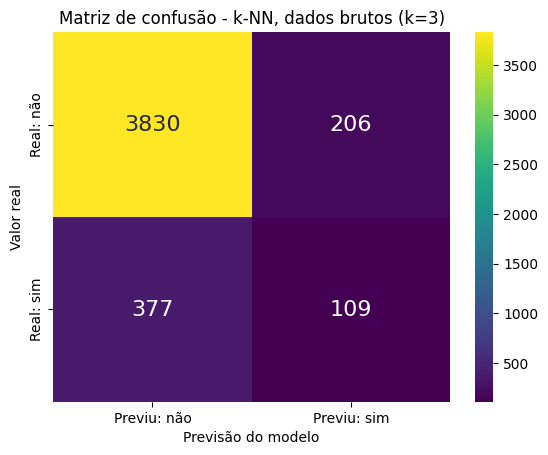

In [254]:
# ---------------------------------------------
# Matriz de confusão 
# ---------------------------------------------

# Define a ordem que as classes võa aparecer na matriz de confusão
ordem_labels = ["no", "yes"]

y_verdadeiro_bruto = Y_teste # Valores reais 
y_previsao_bruto = modelo_bruto.predict(X_teste) # vai adivinhar para cada cliente do conjunto teste com o .predict()

# Monta a matriz de confusão, ou seja, quantas vezes o modelo acertou ou errou cada combinação do real e o previsto
matriz_conf_bruto = confusion_matrix(y_verdadeiro_bruto, y_previsao_bruto, labels=ordem_labels)

# Transforma a matriz, que é um array de números, em um dataframe em que há o índice e colunas dos dados
df_conf_bruto = pd.DataFrame(
    matriz_conf_bruto, index=["Real: não", "Real: sim"], columns=["Previu: não", "Previu: sim"]
)

# Cria a matriz como um heatmap(mapa de calor), onde cada célula vai virar um quadrado colorido de acordo com o seu valor. O fmt ="d" foi utilizado para que o valor dentro dos quadrados apareça como número inteiro ao invés de notação científica (padrão)
eixo = sns.heatmap(df_conf_bruto, annot=True, fmt="d", annot_kws={"size" : 16}, cmap="viridis") # cmpa vai definir a cor utilizada no mapa de calor 
# Vai adicionar os textos ao eixos e o título da forma visual da matriz de confusão. 
eixo.set(xlabel="Previsão do modelo", ylabel="Valor real",
         title="Matriz de confusão - k-NN, dados brutos (k=3)")
plt.show()

Para avaliar se o modelo realmente está aprendendo, ou seja, não está acertando por sorte, utilizamos as métricas para avaliar o desempenho desse modelo. As duas métricas que vão ser utilizadas para essa avaliação são: a acurária e o f1-score, ambas contidas no módulo **sklearn.metrics**

A acurárcia vai ser calculada pela função **acurracy_score**, que calcula a acurácia de acordo com a seguinte expressão [13]: 

$$
\mathrm{ACC = \frac{VP + VN}{VP + FP + VN + FN}}
$$
 
Como padrão, esse métrica mede a fração de previsões corretas feitas pelo modelo. Em nossa previsão feita pelo modelo, ela vai encontrar a porcentagem de classificações certas feitas pelo modelo. Contudo, somente essa métrica não basta para avaliar se o nosso modelo está enviesado ou não. O dataset escolhido é muito desbalenceado, ocorrendo mais "não" em comparação a "sim", sendo possível que modelo preveja "não" para a maioria das entradas.

Como outra maneira de avaliar a aprendizagem, vamos utilizar a medida do f1-score, calculado pela função **F1_score**. Essa função vai calcular a média harmônica entre precisão e recall, atingindo o melhor valor em 1 e o pior em 0, a partir da seguinte expressão[14]: 

$$
\mathrm{F1 = \frac{2VP}{2VP + FP + FN}}
$$

Nessa métrica, os valores verdadeiros positivos são completamente ignorados, já que dizem respeito aos "não" que o modelo acertou, assim, não deixando se enganar pela classe marjoritária dos dados.

In [255]:
# ---------------------------------------------
# Cálculo das métricas 
# ---------------------------------------------

# Acurácia 
acuracia_bruto = accuracy_score(Y_teste, y_previsao_bruto)

# F1-score 
f1_bruto = f1_score(Y_teste, y_previsao_bruto, pos_label="yes")

print(f"Acurácia: {accuracy_score(y_verdadeiro_bruto, y_previsao_bruto)*100:.2f}%")
print(f"F1-score: {f1_score(y_verdadeiro_bruto, y_previsao_bruto, pos_label='yes'):.4f}")

Acurácia: 87.11%
F1-score: 0.2722


Calculados os valores da acurácia e do F1_score, podemos observar que eles obtiveram os valores de, respectivamente, 87.11% e 0.2722. O valor do F1-score foi bem baixo, visto que um bom valor estaria próximo de 1, em comparação ao valor que a acurácia recebeu: quase 3 vezes maior que o F1-score. Essa discrepância é esperada quando o conjunto de dados é muito desbalanceado, já que o modelo tende a prever mais "não" marjoritário em detrimento no "sim". Por esse motivo o valor da acurácia é maior em comparação com o F1-score, visto que ele ignora esse valor marjoritário. 

Uma análise que deve ser levada em consideração para esse conjunto que dados com um um desbalanceamento na escala numérica dos atributos é a importância por permutação. Com a função **permutation_importance** do módulo **sklearn.inspection**, que vai descobrir a importância de um atributo através da queda no score do modelo quando o valor de uma única coluna é embaralhado aleatoriamento[15], e a função **make_scorer** do módulo **sklearn.metrics**, que vai adaptar as métricas ao formato que as ferramentas do sklearn esperam[16], vamos construir o gráfico em barras para visualizar essa importância de cada atributo.

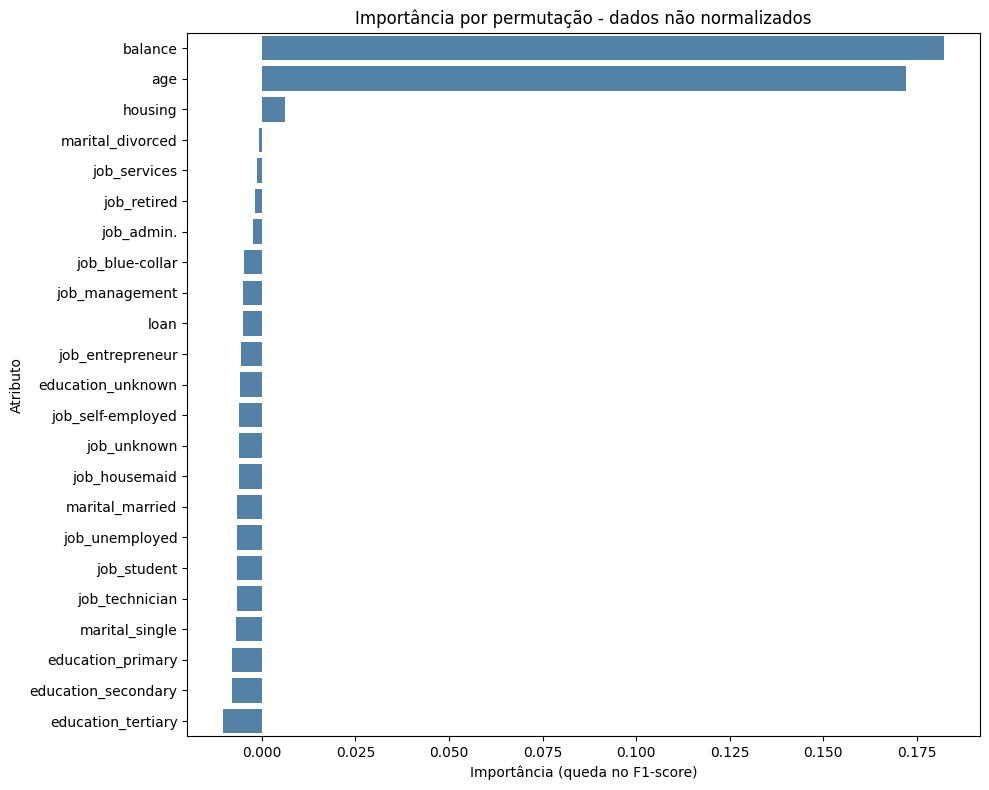

In [256]:
#-------------------------------------------------------------------------------------------
# Análise da importância de cada atributo na escolha do target nos dados não normalizados 
#-------------------------------------------------------------------------------------------

scorer = make_scorer(f1_score, pos_label="yes")

# Para o modelo bruto
importancia_bruto = permutation_importance(
    modelo_bruto, X_teste, Y_teste,
    scoring=scorer, n_repeats=5, random_state=SEMENTE_ALEATORIA, n_jobs=-1
)

df_importancia_bruto = pd.DataFrame({
    "atributo": X_teste.columns,
    "importancia": importancia_bruto.importances_mean
}).sort_values("importancia", ascending=False)

#  Criação do gráfico de barras para a comparação
plt.figure(figsize=(10, 8))
eixo = sns.barplot(data=df_importancia_bruto, x="importancia", y="atributo", color="steelblue")
eixo.set(xlabel="Importância (queda no F1-score)", ylabel="Atributo",
         title="Importância por permutação - dados não normalizados")
plt.tight_layout()
plt.show()

A hipótese mais forte que desenvolvemos na seção do tratamento de dados foi que a a diferença na escala do dos atributos como o age e o balance poderiam acabar carregando a decisão feita pelo modelo, visto que eles teriam pesos maiores que tornariam o restante dos atributos insignificanes na escolha. Ao observar o gráfico da importância por permutação, a hipótese se confirma quando os atributos age e balance, principalmente o balance, carregam todo o peso da decisão. Isso faz com que 20 dos 23 atributos nem sequer colaborem na decisão do modelo. O atributo housing ainda contribuiu muito pouco com essa escolha em comparação aos marjoritários. 

#### KNN com os dados normalizados 

Agora, com os dados normalizados, vamos repetir o processo do KNN com os dados não normalizados, porém, utilizando os dados de treino e teste normalizados.

In [257]:
# ---------------------------------------------
# KNN com os dados brutos 
# ---------------------------------------------

NUM_VIZINHOS = 3 

# Instância 
modelo_norm = KNeighborsClassifier(NUM_VIZINHOS)

# Treinamento 
modelo_norm.fit(X_treino_norm, Y_treino)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Na matriz de confusão com os dados normalizados, podemos observar que houveram 3813 vezes em que o modelo previu "não" e 100 vezes que ele previu "sim" corretamente. Já as previsões erradas ocorreram 386 vezes para "não" e 223 vezes para "sim". Mesmo com a normalização dos dados, as previsões continuam sendo marjoritáriamente para "não" e número de previsões erradas aumentou em relação ao conjunto de dados não normalizados. 

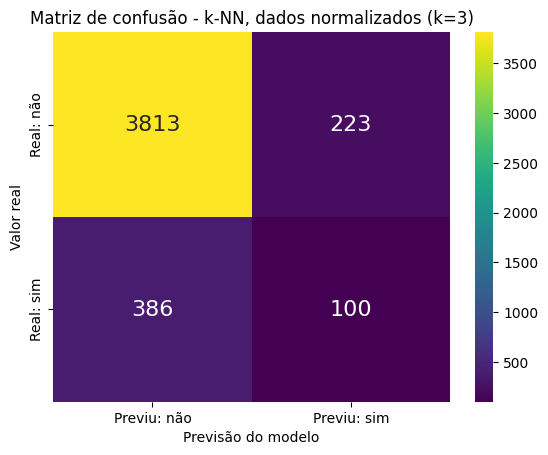

In [258]:
# ---------------------------------------------
# Matriz de confusão 
# ---------------------------------------------

# Ordem das classes 
ordem_labels = ["no", "yes"]

y_verdadeiro_norm = Y_teste
y_previsao_norm = modelo_norm.predict(X_teste_norm)

# Montagem da matriz de confusão 
matriz_conf_norm = confusion_matrix(y_verdadeiro_norm, y_previsao_norm, labels=["no", "yes"])
df_conf_norm = pd.DataFrame(
    matriz_conf_norm, index=["Real: não", "Real: sim"], columns=["Previu: não", "Previu: sim"]
)

# Heatmap(mapa de calor)
eixo = sns.heatmap(df_conf_norm, annot=True, fmt="d", annot_kws={"size" : 16}, cmap="viridis")
eixo.set(xlabel="Previsão do modelo", ylabel="Valor real",
         title="Matriz de confusão - k-NN, dados normalizados (k=3)")
plt.show()

É possível perceber que as métricas calculadas para os dados normalizados foram pirores em comparação àqueles que não foram normalizados. O modelo alcançou a acurácia de 86.53% e o F1-score de 0.2472. Na seção de tratamento dos atributos, foi discutido que a normalização poderia melhorar essa diferença de escala que acompanha dois atributos alvo desse treinamento, mas podemos perceber que há outro obstáculo para essa melhoria: a distribuição de importância dos atributos.

In [259]:
# ---------------------------------------------
# Cálculo das métricas 
# ---------------------------------------------

# Acurácia 
acuracia_norm = accuracy_score(Y_teste, y_previsao_norm)

# F1-score 
f1_norm = f1_score(Y_teste, y_previsao_norm, pos_label="yes")

print(f"Acurácia: {accuracy_score(y_verdadeiro_norm, y_previsao_norm)*100:.2f}%")
print(f"F1-score: {f1_score(y_verdadeiro_norm, y_previsao_norm, pos_label='yes'):.4f}")

Acurácia: 86.53%
F1-score: 0.2472


Diferentemente da distribuição dos dados não normalizados, os dados normalizados permitem que outros atributos, além daquels que dominaram completamente o gráfico anterior, possam ter peso na escolha feita pelo modelo. Isso vai acarretar na perda da decisão final abrangentemente dos atributos age e balance, assim, diminuindo os valores da acurácia e F1-score do modelo. A primeira vista, essa diminuição aparenta ter um aspecto negativo, mas, como explicado, ela está deixando o modelo com uma distribuição de escolha mais diluida. Contudo, o poder de decisão mais bem distribuído não garantiu que os valores da métricas que avaliam os modelos apresentassem melhora em relação aos dados brutos. Portanto, podemos considerar que a normalização, nesse caso, não acarretou em melhoras no desempenho do modelo. 

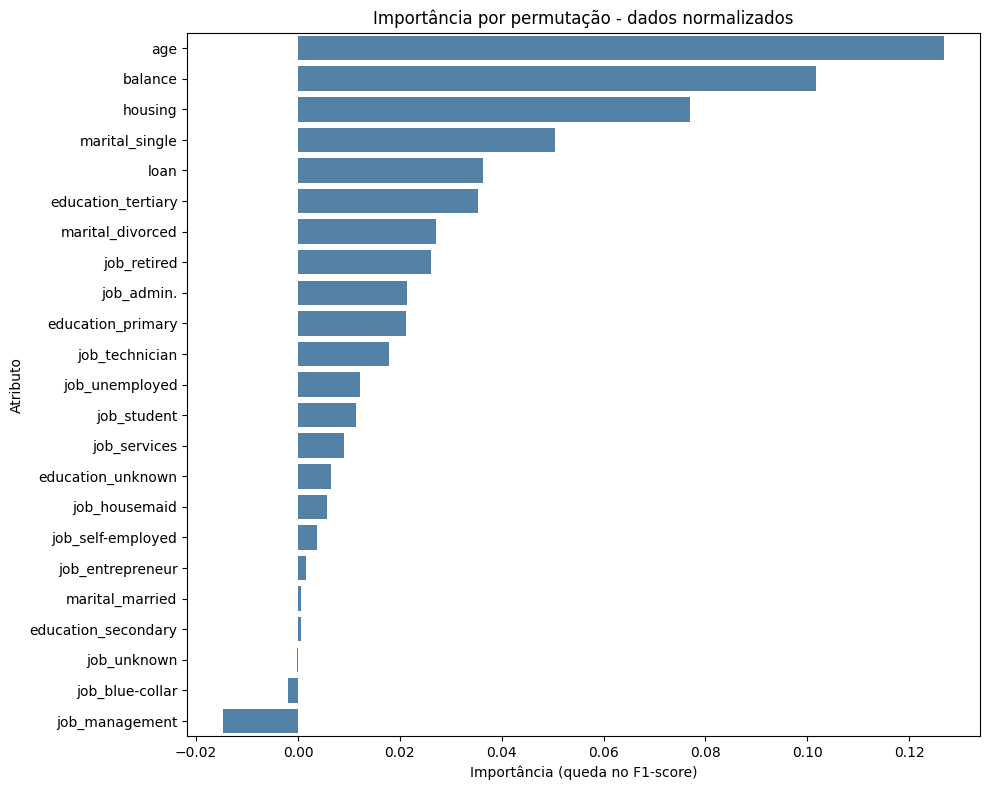

In [260]:
#---------------------------------------------------------------------------------------
# Análise da importância de cada atributo na escolha do target nos dados normalizados 
#--------------------------------------------------------------------------------------

scorer = make_scorer(f1_score, pos_label="yes")

# Para o modelo bruto
importancia_norm = permutation_importance(
    modelo_norm, X_teste_norm, Y_teste,
    scoring=scorer, n_repeats=5, random_state=SEMENTE_ALEATORIA, n_jobs=-1
)

df_importancia_norm = pd.DataFrame({
    "atributo": X_teste_norm.columns,
    "importancia": importancia_norm.importances_mean
}).sort_values("importancia", ascending=False)

#  Criação do gráfico de barras para a comparação
plt.figure(figsize=(10, 8))
eixo = sns.barplot(data=df_importancia_norm, x="importancia", y="atributo", color="steelblue")
eixo.set(xlabel="Importância (queda no F1-score)", ylabel="Atributo",
         title="Importância por permutação - dados normalizados")
plt.tight_layout()
plt.show()

### Definição e análise dos hiperparâmetros 

Hiperparâmetros são parâmetros que não são diretamente aprendidos com os estimadores, mas que aprende sozinho durante o treinamento do modelo[Sk]. Eles são defidos antes de propriamente treinar o modelo. Essa variação vai ser feita através da função **product**, do módulo **itertools**, que vai gerar todas as combinações possíveis entre os valores dos hiperparâmetros escolhidos. Após isso, cada combinação vai treinar individualmente um modelo e gerar uma acurácia e F1-score para eles. Perceba que fizemos isso no treinamento dos KNNs acima, porém variando somente uma vez. Na variação, o modelo vai ser treinado diversas vezes de acordo com o a combinação de hiperparâmetros. Foram escolhidos a variação de dois tipos de hiperparâmtros: o número de vizinhos e o tipo de função de distância utilizada. Para os vizinhos, foram variados entre 8 números de vizinhos diferentes: 1, 3, 5, 7, 9, 11, 15 e 21. Já as funções de distância foram variadas dentre 3 diferentes: euclidiana, manhattan e chebyshev. O produto desses hiperparâmetros contabiliza em 24 conjuntos de variações diferentes que vão ser testadas. 

A discussão anterior sobre a utilização dos dados não normalizados e normalizados nos incentiva a fazer uma escolha importânte para a variação de hiperâmetros: qual dos dados utilizar para variar os hiperparâmetros? Visto que o KNN com dados não normalizados superou em eficácia, tanto o F1-score quanto a acurácia, o KNN com os dados normalizados, o que foge do que as literaturas aconselham utilizar, vamos utilizar os dados que obtiveram maior eficácia: os dados não normalizados.

#### Hiperparâmetros com dados não normalizados

A seguir, vamos realizar a variação de hiperparâmetros, comentada anteriormente, com os dados não normalizados. 

In [64]:
# ---------------------------------------------
# Definição dos hiperparâmetros com os dads brutos 
# ---------------------------------------------

# Definição dos hiperparâmetros que vão gerar o produto cartesiano de todas as combinações possíveis
VALORES_K = [1, 3, 5, 7, 9, 11, 15, 21]  # ímpares, para evitar empate de votos
FUNCOES_DISTANCIA = ["euclidean", "manhattan", "chebyshev"] 

# Lista que vai guardar o resultados de cada uma das combinações testadas. Isso possibilita criar o df_resultados futuramente
resultados_brutos = []

# O loop que vai gerar todas as combinações possíveis entre os hiperparâmetros definidos
for k, funcao_distancia in product(VALORES_K, FUNCOES_DISTANCIA):
    # Instanciamos o modelo com esses valores, pois o modelo não pode ser reaproveitado para o próximo, mas deve ser instanciado novamente 
    modelo = KNeighborsClassifier(
        n_neighbors=k,
        metric=funcao_distancia,
    )

    # Treinamento do modelo 
    modelo.fit(X_treino, Y_treino)

    Y_verdadeiro = Y_teste
    # Previsão do modelo 
    Y_previsao = modelo.predict(X_teste)
    # F1-score
    F1 = f1_score(Y_verdadeiro, Y_previsao, pos_label="yes")
    # Acurácia 
    ACURACIA = accuracy_score(Y_verdadeiro, Y_previsao)

    print(
        f"O F1-score do modelo k-NN usando k={k} "
        f"e distância={funcao_distancia} foi de {F1:.4f} (acurácia: {ACURACIA*100:.1f}%)."
    )

    # O desempenho do modelo depende dos hiperparâmetros. Quanto maior o F1-score, melhor foi o desempenho
    resultados_brutos.append({"k": k, "funcao_distancia": funcao_distancia, "f1_score": F1, "acuracia": ACURACIA})

# Guarda os resultados em um dataframe após a finalização do loop
df_resultados_brutos = pd.DataFrame(resultados_brutos)

O F1-score do modelo k-NN usando k=1 e distância=euclidean foi de 0.3176 (acurácia: 83.7%).
O F1-score do modelo k-NN usando k=1 e distância=manhattan foi de 0.3287 (acurácia: 84.1%).
O F1-score do modelo k-NN usando k=1 e distância=chebyshev foi de 0.2810 (acurácia: 82.6%).
O F1-score do modelo k-NN usando k=3 e distância=euclidean foi de 0.2722 (acurácia: 87.1%).
O F1-score do modelo k-NN usando k=3 e distância=manhattan foi de 0.2685 (acurácia: 86.9%).
O F1-score do modelo k-NN usando k=3 e distância=chebyshev foi de 0.2240 (acurácia: 87.3%).
O F1-score do modelo k-NN usando k=5 e distância=euclidean foi de 0.1821 (acurácia: 88.1%).
O F1-score do modelo k-NN usando k=5 e distância=manhattan foi de 0.1761 (acurácia: 87.8%).
O F1-score do modelo k-NN usando k=5 e distância=chebyshev foi de 0.1529 (acurácia: 88.0%).
O F1-score do modelo k-NN usando k=7 e distância=euclidean foi de 0.1164 (acurácia: 88.6%).
O F1-score do modelo k-NN usando k=7 e distância=manhattan foi de 0.1117 (acurác

Com auxílio de heatmap(mapa de calor) criado com auxílio da função **heatmap**, do módulo **seaborn**, podemos visualizar como o valor do F1-score se comportou ao longo de variações feitas no número de vizinhos do KNN e das funções de distância utilizadas. Essas variações nos permitiram perceber que a melhor combinação de hiperparâmetros correspondeu ao número de vizinhos igual a 1 e a função de distância manhattan. 

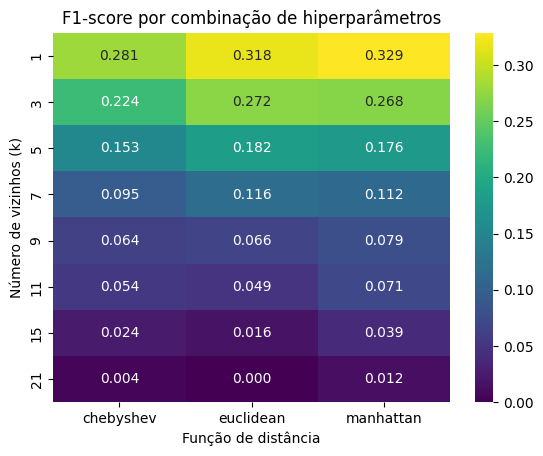

In [261]:
# Organiza os dados para a criação do heatmap do F1-score dos dados brutos 
tabela_pivot_F1 = df_resultados_brutos.pivot(index="k", columns="funcao_distancia", values="f1_score")

# Cria o heatmap da combinação de hiperparâmetros com os dados brutos evidenciando os diferentes valores do F1-score 
eixo = sns.heatmap(tabela_pivot_F1, annot=True, fmt=".3f", cmap="viridis")
eixo.set(xlabel="Função de distância", ylabel="Número de vizinhos (k)",
         title="F1-score por combinação de hiperparâmetros");

Percebido o melhor desempenho dessa combinação específica, vamos observar o caminho que a variação dos vizinhos para a função de distância manhattan causa no comportamento das nossas métricas alvo. Esse gráfico vai ser criado com auxílio do módulo **matplotlib.pyplot**.

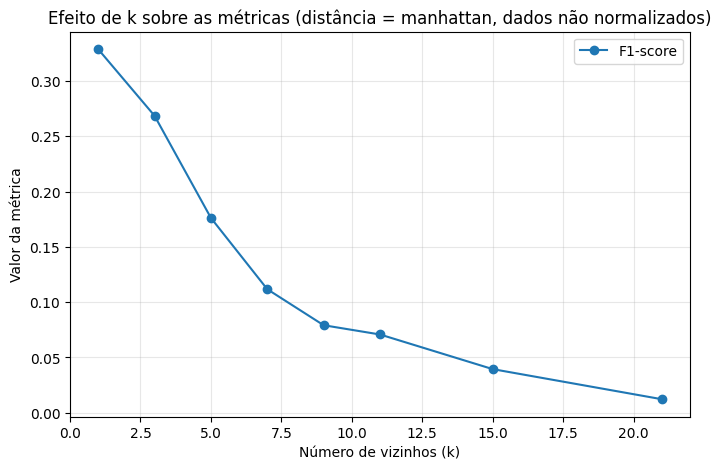

In [262]:
import matplotlib.pyplot as plt

# Fixando a função de distância no melhor caso encontrado (manhattan) e variando k
subset = df_resultados_brutos[df_resultados_brutos["funcao_distancia"] == "manhattan"]

plt.figure(figsize=(8, 5))
plt.plot(subset["k"], subset["f1_score"], marker="o", label="F1-score")
plt.xlabel("Número de vizinhos (k)")
plt.ylabel("Valor da métrica")
plt.title("Efeito de k sobre as métricas (distância = manhattan, dados não normalizados)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

No gráfico é perceptível que o aumento no número de vizinhos acarreta na diminuição do F1-score da melhor combinação encontrada anteriormente. Uma hipótese para esse comportamente é que, devido ao desbalanceamento do conjunto de dados, o aumento no número de vizinhos vai diluir mais o poder de decisão em favor da classe que tem mais peso nas decisões. Assim, da mesma maneira que ocorreu no KNN com os dados normalizados, essa melhor distribuição do poder de escolha vai acarretar na piora do F1-score.

### Modelo Baseline 

O modelo Baseline consiste vai utilizar a função **DummyClassifier**, do módulo **sklearn.dummy**, que vai fazer previsões que ignoram completamente os atributos de entrada, servindo somente como uma referência simples para comparar com classificadores mais complexos[17]. Assim, o baseline vai olhar somente para a coluna do target: y. As variações entre os dados normalizados e não normalizados não vai ser feita aqui, pois o DummyClassifier utiliza, por padrão, a estratágia "prior", que ignora os atributos de entrada. Então, normalizar não tem nenhum efeito nesse caso. 

In [263]:
# ---------------------------------------------
# Baseline 
# ---------------------------------------------

# Ordem das classes 
ordem_labels = ["no", "yes"]

# Instância 
modelo_baseline = DummyClassifier()

# Treinamento 
modelo_baseline.fit(X_treino, Y_treino)

,strategy,'prior'
,random_state,None
,constant,None


Observando a matriz de confusão desse modelo, temos que o modelo acertou "não" 4036 vezes e "sim" 0 vezes. Já nos erros, ele obteve 486 vezes para "não" e 0 vezes para "sim". Isso indica que, discrepantemente, o modelo previu somente respostas "não" e nenhuma resposta "sim", indicando que esse modelo é totalmente ineficaz para prever quais clientes adeririam ao empréstimo. 

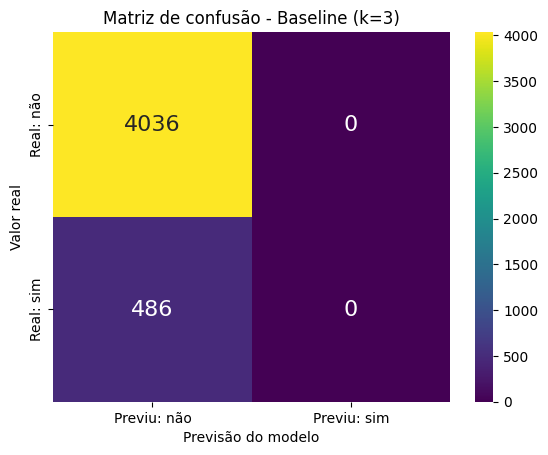

In [264]:
# ---------------------------------------------
# Matriz de confusão 
# ---------------------------------------------

y_verdadeiro = Y_teste
y_previsao = modelo_baseline.predict(X_teste)

# Montagem da matriz de confusão 
matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_base = pd.DataFrame(
    matriz_conf, index=["Real: não", "Real: sim"], columns=["Previu: não", "Previu: sim"]
    )

# Heatmap(mapa de calor)
eixo = sns.heatmap(df_conf_base, annot=True, fmt="d", annot_kws={"size" : 16}, cmap="viridis")
eixo.set(xlabel="Previsão do modelo", ylabel="Valor real",
         title="Matriz de confusão - Baseline (k=3)")
plt.show()

Observando a acurácia, podemos ter a falsa sensação de que o modelo é muito eficaz, já que ele prevê 89.25% das vezes corretamente. Porém, observando o valor do F1-score retorna, ele nos diz o contrário: o modelo teve eficácia 0 em prever quando o modelo acertaria que o cliente pediria o empréstimo. 

In [265]:
# ---------------------------------------------
# Cálculo das métricas 
# ---------------------------------------------

# Acurácia 
acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

# F1-score 
f1_baseline = f1_score(y_verdadeiro, y_previsao, pos_label="yes")

print(f"Acurácia = {acuracia_baseline*100:.2f}%")
print(f"F1-score = {f1_baseline:.4f}")

Acurácia = 89.25%
F1-score = 0.0000


Vizualizando com o auxílio de uma gráfico de barras, podemos ver a diferença entre o real e o previsto pelo baseline. É possível perceber que o baseline previu totalmente as escolhas dos clientes como que não adeririam ao empréstimo, bem diferente dos dados reais. 

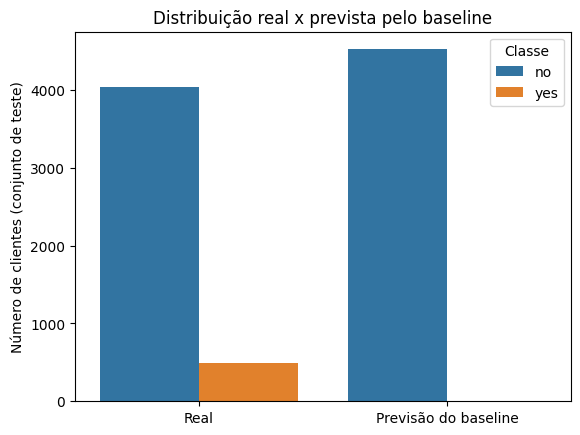

In [266]:
# -------------------------------------------------------------
# Distribuição real vs distribuição prevista pelo baseline 
# -------------------------------------------------------------

# Criação do dataframe que reorganiza os dados para o gráfico real x previsto do baseline
comparacao = pd.DataFrame({
    "origem": ["Real"] * len(Y_teste) + ["Previsão do baseline"] * len(y_previsao),
    "classe": list(Y_teste) + list(y_previsao),
})

#  Criação do gráfico de barras para a comparação
eixo = sns.countplot(data=comparacao, x="origem", hue="classe")
eixo.set(xlabel="", ylabel="Número de clientes (conjunto de teste)",
         title="Distribuição real x prevista pelo baseline")
eixo.legend(title="Classe");

### Comparação da eficácia entre Baseline e KNN 

Finalizadas todas as análises realizadas no decorrer do notebook envolvendo as variações do KNN e o modelo baseline, vamos comparar os resultados obtidos com esse dois modelos.

In [268]:
# pega, pra cada distância, a linha com o maior F1-score entre os k testados (dados não normalizados)
melhor_por_distancia = df_resultados_brutos.loc[df_resultados_brutos.groupby("funcao_distancia")["f1_score"].idxmax()]

# reorganiza esse resultado no formato "modelo/acurácia/f1_score" pra juntar com baseline e k-NN bruto
linhas_distancia = []
for _, linha in melhor_por_distancia.iterrows():
    linhas_distancia.append({
        "modelo": f"k-NN ({linha['funcao_distancia']}, k={int(linha['k'])})",
        "acuracia": linha["acuracia"],
        "f1_score": linha["f1_score"],
    })

# tabela final: baseline + k-NN bruto (k=3) + melhor k-NN normalizado de cada distância
tabela_comparacao = pd.concat([
    pd.DataFrame({
        "modelo": ["Baseline", "k-NN (dados brutos, k=3)"],
        "acuracia": [acuracia_baseline, acuracia_bruto],
        "f1_score": [f1_baseline, f1_bruto],
    }),
    pd.DataFrame(linhas_distancia),
], ignore_index=True)

tabela_comparacao

,modelo,acuracia,f1_score
0,Baseline,0.892525,0.000000
1,"k-NN (dados brutos, k=3)",0.871075,0.272160
2,"k-NN (chebyshev, k=1)",0.825741,0.281022
3,"k-NN (euclidean, k=1)",0.836577,0.317636
4,"k-NN (manhattan, k=1)",0.841000,0.328665


Observando a comparação dos valores no gráfico abaixo, dentre todos os modelos, o baseline foi o que apresentou o pior desempenho de todos em questão da acurácia. Dentre os melhores F1-score por função de distância, temos que a variação deo hiperparâmtro com manhattan e o k=1 foi a melhor métrica dentre todas. Como discutido anteriormente sobre a acurácia, podemos concluir que a mesma não pode dizer muito sobre o desempenho do modelo por conta da má distribuição dos dados do conjunto. 

Aqui, fica percepitível a importância das informações que as variáveis de interesse carregam sobre a adesão do produto. Isso se mostra de modo que no baseline, que ignora esses atributos, o valor do F1-score é nulo, enquanto a acurácia transmite um falso resultado positivo para o modelo. 

Por mais que o modelo que tem a melhor métrica(manhattan e k=1) ainda erre mais no total que o baseline, ele ainda consegue transmitir informações mais úteis sobre o modelo, pois consegue identificar mais potenciais clientes que o outro modelo - que identifica todos como não potenciais clientes. 

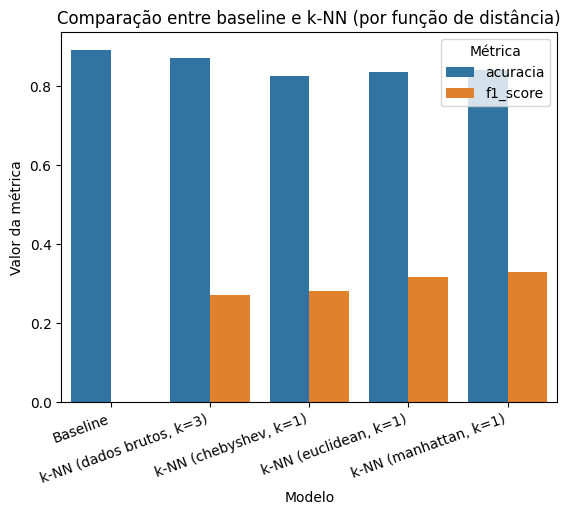

In [269]:
# formato "longo" (uma linha por métrica) para o gráfico de barras agrupadas
tabela_longa = tabela_comparacao.melt(id_vars="modelo", var_name="metrica", value_name="valor")

eixo = sns.barplot(data=tabela_longa, x="modelo", y="valor", hue="metrica")
eixo.set(xlabel="Modelo", ylabel="Valor da métrica", title="Comparação entre baseline e k-NN (por função de distância)")
eixo.legend(title="Métrica")
plt.xticks(rotation=20, ha="right");

##  Conclusões e principais aprendizados 

Conclui-se que a escolha do banco de dados influencia muito em como o modelo vai ser treinado. Todas as escolhas foram baseadas em como a má distribuição das respostas yes/no do target categórico escolhido poderiam se comportar de melhor maneira no modelo. Outra conclusão enriquecedora que o treinamento do modelo com esses dados nos proporciona é como a normalização não foi capaz de melhorar a eficácia no modelo quanto as métricas escolhidas para avaliar o desempenho do modelo. Foi possível perceber que quanto mais diluida ficou a distribuição no poder da escollha da previsão feita pelo modelo, pior acurácia e F1-score o modelo apresentava. Nesse treinamento de modelo, a acurácia se mostoru uma métrica que nos enganou com seus resultados, trazendo muitas vezes resultados muito altos(próximo a 100%) que não agregavam na avaliação do modelo como bom. 

Durante toda a confeccção desse notebook, foi possível aprender muito mais sobre as bibliotecas utilizadas. Dentre elas estão os módulos do scikitlearn que foram parte chave para treinar o modelo, fazer a nomalização dos dados, gravando a memória dos treinos feitos e muitas outras funções desempenhadas. Além desse módulo, muito foi aprendido sobre o módulo pandas e o módulo seaborn, acompanhados com suas funções que auxiliaram em diversos âmbitos da análise, construção de gráficos e dataframes. 

## Referências bibliográficas 

[1] FACELI, Katti; LORENA, Ana Carolina; GAMA, João; et al. Inteligência Artificial: uma abordagem de Aprendizado de Máquina. 2. ed. Rio de Janeiro: LTC, 2021.

[2] MORO, Sérgio; CORTEZ, Paulo; RITA, Paulo. A data-driven approach to predict the success of banl telemarketing. Decision Support System, v. 62, p. 22-31, 2014. DOI: <https://doi.org/10.1016/j.dss.2014.03.001>. Acesso em 13 set. 2026. 

[3] SCIKIT-LEARN. KNeighbrosClassifier. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html>. Acesso em: 13 set. 2026.

[4] WIKIPEDIA. Euclidian distance. Disponível em: <https://en.wikipedia.org/wiki/Euclidean_distance>. Acesso em: 13 set. 2026. 

[5] WIKIPEDIA. Taxicab geometry. Disponível em: <https://en.wikipedia.org/wiki/Taxicab_geometry>. Acesso em: 13 set. 2026.

[6] WIKIPEDIA. Chebshev distance. Disponível em: <https://en.wikipedia.org/wiki/Chebyshev_distance>. Acesso em: 13 set. 2026.

[7] MORO, Sérgio; CORTEZ, Paulo; RITA, Paulo. Bank Marketing [dataset]. UCI Machine Learning Repository, 2014. DOI:10.24432/C5K306. Disponível em: <https://uci-ics-mlr-prod.aws.uci.edu/dataset/222/bank+marketing>. Acesso em: 13 set. 2026.

[8] SCIKIT-LEARN. sklearn.model_selection.train_test_split. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html>. Acesso em: 13 set. 2026. 

[9] SCIKIT-LEARN. 8.3. Preprocessing data: Encoding categorical features. Disponível em: <https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features>. Acesso em: 13 set. 2026. 

[10] THE PANDAS DEVELOPMENT TEAM. GroupBy: split-apply-combine. In: pandas documentation. Disponível em: <https://pandas.pydata.org/docs/user_guide/groupby.html>. Acesso em: 13 set. 2026.

[11] SCIKIT-LEARN. 3.4. Metrics and scoring: quantifying the quality of predictions — Confusion matrix. Disponível em: <https://scikit-learn.org/stable/modules/model_evaluation.html#confusion-matrix>. Acesso em: 13 set. 2026.

[12] WIKIPEDIA. Confusion matrix. Disponível em: <https://en.wikipedia.org/wiki/Confusion_matrix>. Acesso em: 13 set. 2026.

[13] SCIKIT-LEARN. sklearn.metrics.accuracy_score. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html>. Acesso em: 13 set. 2026.

[14] SCIKIT-LEARN. sklearn.metrics.f1_score. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html>. Acesso em: 13 set. 2026.

[15] SCIKIT-LEARN. sklearn.inspection.permutation_importance. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html>. Acesso em: 13 set. 2026.

[16] SCIKIT-LEARN. sklearn.metrics.make_scorer. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html>. Acesso em: 13 set. 2026.

[17] SCIKIT-LEARN. sklearn.dummy.DummyRegressor. Disponível em: <https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyRegressor.html>. Acesso em: 13 set. 2026.

## Declaração do uso de IA 

Declaro que utilizei a Inteligência Artificial(IA) Claude Sonnet 5, desenvolvida pelo Antropic. Essa IA foi utilizada na forma de discutir hipóteses, melhores escolhas, aprender novas formas de análisar os resultados e representá-los para o leitor, bem como aprender mais sobre o módulo sklearn, amplamente utilizado para treinar o modelo no decorrer do notebook. No link abaixo, temos a trajetória da conversa com essa IA: https://claude.ai/share/9c3aa146-0ba5-4c67-bd2a-9430963afdd8